In [1]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt 
from dbconfig import engine 
print('Environment ready!')

Environment ready!


In [2]:
from pathlib import Path 

plots_dir = Path('plots')
plots_dir.mkdir(exist_ok = True)

In [3]:
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_float_precision(2)
pl.Config.set_thousands_separator(",")

polars.config.Config

In [4]:
pl.read_database(
        query = """
        select table_name,
        column_name
        from information_schema.columns 
        where table_schema = 'clean'
        and table_name in ('orders', 'reviews')
        order by table_name, ordinal_position;
        """, connection = engine
        )

table_name,column_name
str,str
"""orders""","""order_id"""
"""orders""","""customer_id"""
"""orders""","""order_status"""
"""orders""","""order_purchase_timestamp"""
"""orders""","""order_approved_at"""
"""orders""","""order_delivered_carrier_date"""
"""orders""","""order_delivered_customer_date"""
"""orders""","""order_estimated_delivery_date"""
"""reviews""","""review_id"""


In [6]:
pl.read_database(
        query = """
        select count(*) as rows,
        count(distinct order_id) as orders
        from clean.reviews;
        """, connection  = engine
        )

rows,orders
i64,i64
"99,224","98,673"


In [8]:
delivery_vs_review = pl.read_database(
        query = """
        select o.order_id,
        max(r.review_score) as review_score,
        
        extract(
            day from(
                o.order_delivered_customer_date 
                - o.order_purchase_timestamp
                )
            ) as delivery_days,

        extract(
            day from(
                o.order_delivered_customer_date 
                - o.order_estimated_delivery_date
                )
            ) as delay_days

        from clean.orders o 
        join clean.reviews r 
        on o.order_id = r.order_id 

        where o.order_status = 'delivered'
        
        group by o.order_id
        """, connection = engine
        )

In [9]:
delivery_vs_review = delivery_vs_review.drop_nulls()

In [22]:
delivery_vs_review.head()

order_id,review_score,delivery_days,delay_days
str,i64,"decimal[38,0]","decimal[38,0]"
"""00010242fe8c5a6d1ba2dd792cb16214""",5,7,-8
"""00018f77f2f0320c557190d7a144bdd3""",4,16,-2
"""000229ec398224ef6ca0657da4fc703e""",5,7,-13
"""00024acbcdf0a6daa1e931b038114c75""",4,6,-5
"""00042b26cf59d7ce69dfabb4e55b4fd9""",5,25,-15


In [10]:
delivery_vs_review.describe()

statistic,order_id,review_score,delivery_days,delay_days
str,str,f64,f64,f64
"""count""","""95,824""","95,824.00","95,824.00","95,824.00"
"""null_count""","""0""",0.00,0.00,0.00
"""mean""",null,4.16,12.05,-10.99
"""std""",null,1.28,9.47,9.95
"""min""","""00010242fe8c5a6d1ba2dd792cb16214""",1.00,0.00,-146.00
"""25%""",null,4.00,6.00,-16.00
"""50%""",null,5.00,10.00,-11.00
"""75%""",null,5.00,15.00,-6.00
"""max""","""fffe41c64501cc87c801fd61db3f6244""",5.00,208.00,188.00


In [11]:
delivery_vs_review_summary = (
    delivery_vs_review
    .group_by("review_score")
    .agg(
        pl.len().alias("orders"),
        pl.median("delivery_days").alias("median_delivery_days"),
        pl.mean("delivery_days").round(2).alias("avg_delivery_days"),
        pl.median("delay_days").alias("median_delay_days"),
        pl.mean("delay_days").round(2).alias("avg_delay_days"),
        (pl.col("delay_days") > 0)
            .mean()
            .mul(100)
            .round(2)
            .alias("late_pct")
    )
    .sort("review_score")
)

In [12]:
delivery_vs_review_summary

review_score,orders,median_delivery_days,avg_delivery_days,median_delay_days,avg_delay_days,late_pct
i64,u32,f64,f64,f64,f64,f64
1,"9,312",16.00,20.88,-6.00,-3.39,36.79
2,"2,912",13.00,16.18,-9.00,-7.84,18.89
3,"7,900",12.00,13.80,-10.00,-9.87,8.80
4,"18,890",10.00,11.84,-11.00,-11.43,3.45
5,"56,810",9.00,10.22,-12.00,-12.41,1.86


In [13]:
from scipy.stats import spearmanr

In [16]:
stat, p = spearmanr(
    delivery_vs_review["delivery_days"],
    delivery_vs_review["review_score"]
)

print(f"stat: {stat:.4f}, p: {p:.4f}")

stat: -0.2342, p: 0.0000


In [17]:
stats, ps = spearmanr(
    delivery_vs_review["delay_days"],
    delivery_vs_review["review_score"]
)

print(f"stat: {stats:.4f}, p: {ps:.4f}")

stat: -0.1762, p: 0.0000


In [24]:
late = delivery_vs_review.filter(pl.col("delay_days") > 0)["review_score"]

on_time = delivery_vs_review.filter(pl.col("delay_days") <= 0)["review_score"]

In [25]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    late,
    on_time,
    alternative="two-sided"
)

print(f"U = {stat:.0f}")
print(f"p = {p:.4g}")

U = 103402346
p = 0


In [26]:
(
    delivery_vs_review
    .with_columns(
        (pl.col("delay_days") > 0).alias("late_delivery")
    )
    .group_by("late_delivery")
    .agg(
        pl.len().alias("orders"),
        pl.median("review_score").alias("median_review"),
        pl.mean("review_score").round(2).alias("avg_review")
    )
)

late_delivery,orders,median_review,avg_review
bool,u32,f64,f64
false,"89,443",5.00,4.29
true,"6,381",1.00,2.27


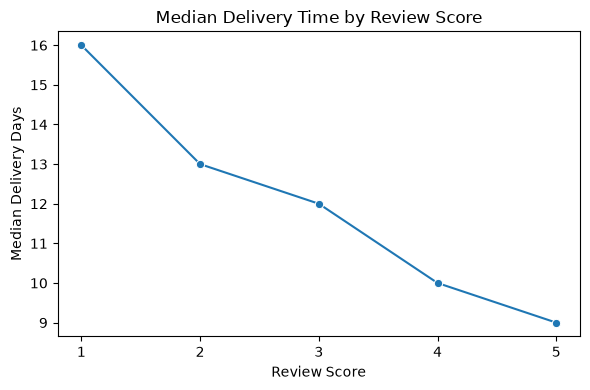

In [47]:
plt.figure(figsize=(6, 4))

sns.lineplot(
    data=delivery_vs_review_summary.to_pandas(),
    x="review_score",
    y="median_delivery_days",
    marker="o",
)

plt.title("Median Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Median Delivery Days")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(
    "plots/review_vs_delivery_days.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

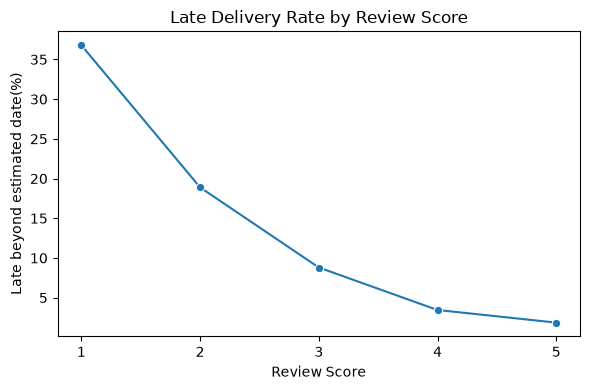

In [48]:
plt.figure(figsize=(6, 4))

sns.lineplot(
    data=delivery_vs_review_summary.to_pandas(),
    x="review_score",
    y="late_pct",
    marker="o",
)

plt.title("Late Delivery Rate by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Late beyond estimated date(%)")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(
    "plots/review_vs_late_pct.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [49]:
delivery_vs_review_summary.write_database(
    table_name="analytics.review_delivery_summary",
    connection=engine,
    if_table_exists="replace"
)

-1